In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df=pd.read_csv('Cleaned_Salary.csv')

In [9]:
df.columns

Index(['title', 'company', 'location', 'salary', 'rating', 'hourly', 'min_sal',
       'max_sal', 'avg_salary', 'city', 'state'],
      dtype='object')

In [10]:
df.shape


(605, 11)

In [11]:
df['title']

0                                    Risk Data Scientist
1                               Associate Data Scientist
2                                         Data Scientist
3                                   Data Scientist I, II
4                                         Data Scientist
                             ...                        
600                       Senior Data Scientist (AdTech)
601    Junior Research Engineer - Machine Learning Sy...
602                                Senior Data Scientist
603      Machine Learning Engineer - Foundational Models
604                 Biomedical Machine Learning Engineer
Name: title, Length: 605, dtype: object

In [30]:
def title_simplifier(title):
    if 'data scientist' in title.lower():
        return 'data scientist'
    elif 'data engineer' in title.lower():
        return 'data engineer'
    elif 'analyst' in title.lower():
        return 'analyst'
    elif 'machine learning' in title.lower():
        return 'mle'
    elif 'manager' in title.lower():
        return 'manager'
    elif 'director' in title.lower():
        return 'director'
    elif 'research' in title.lower():
        return 'research position'    
    else:
        return 'na'
def seniority(title):
    if 'sr' in title.lower() or 'senior' in title.lower() or 'sr' in title.lower() or 'lead' in title.lower() or 'principal' in title.lower():
        return 'senior'
    elif 'jr' in title.lower() or 'jr.' in title.lower():
        return 'jr'
    else:
        return 'na'      

In [31]:
df['job_simp']=df['title'].apply(title_simplifier)


In [32]:
df.job_simp.head()

0    data scientist
1    data scientist
2    data scientist
3    data scientist
4    data scientist
Name: job_simp, dtype: object

In [33]:
df.job_simp.value_counts()

job_simp
data scientist       552
na                    23
mle                   16
analyst                9
research position      3
data engineer          1
manager                1
Name: count, dtype: int64

In [35]:
df['job_seniority']=df.title.apply(seniority)

In [36]:
df['job_seniority'].value_counts()

job_seniority
na        453
senior    150
jr          2
Name: count, dtype: int64

In [38]:
df.state.value_counts()

state
 CA       137
Remote     96
 NY        42
 TX        39
 VA        33
 IL        24
 OH        22
 WA        20
 GA        20
 NJ        19
 CO        19
 DC        19
 MD        14
 PA        13
 MA        11
 UT         9
 AZ         7
 FL         7
 NC         6
 IN         5
 PR         4
 AR         4
 MN         4
 MO         4
 MI         3
 WI         3
 TN         3
 NV         2
 NM         2
 AL         2
 SC         2
 LA         1
 NH         1
 OK         1
 IA         1
 KY         1
 OR         1
 CT         1
 NE         1
 ME         1
 HI         1
Name: count, dtype: int64

In [39]:
df.columns


Index(['title', 'company', 'location', 'salary', 'rating', 'hourly', 'min_sal',
       'max_sal', 'avg_salary', 'city', 'state', 'job_simp', 'job_seniority'],
      dtype='object')

In [54]:
df.min_sal=df.apply(lambda x : x.min_sal * 2 if x.hourly==1 else x.min_sal, axis=1)
df.max_sal=df.apply(lambda x : x.max_sal * 2 if x.hourly==1 else x.max_sal, axis=1)

In [70]:
df.loc[df['hourly'] == 1, ['hourly', 'min_sal', 'max_sal','city','company']]

,hourly,min_sal,max_sal,city,company
5,1,160.00,180.00,Remote,GenuineXs LLC
73,1,50.00,80.00,United States,Continuum Resource Network
79,1,50.00,200.00,United States,Oland Technologies
84,1,170.00,180.00,Sunnyvale,Skyelia
88,1,110.22,124.00,Dallas,Pebal Bright Technologies LLC
131,1,100.08,130.00,Santa Clara,Hecta Data (DBA) Vilwaa
145,1,180.00,200.00,Deerfield Beach,CTI Consulting
157,1,100.00,100.00,Malvern,Intone Networks
158,1,33.66,151.26,Austin,Amazon.com Services LLC
169,1,70.00,80.00,Cambridge,Pfizer


In [61]:
temp=pd.read_csv('Cleaned_Salary.csv')

In [67]:
temp.loc[temp['hourly'] == 1, ['hourly', 'min_sal', 'max_sal','city','company']]

,hourly,min_sal,max_sal,city,company
5,1,160.00,180.00,Remote,GenuineXs LLC
73,1,50.00,80.00,United States,Continuum Resource Network
79,1,50.00,200.00,United States,Oland Technologies
84,1,170.00,180.00,Sunnyvale,Skyelia
88,1,110.22,124.00,Dallas,Pebal Bright Technologies LLC
131,1,100.08,130.00,Santa Clara,Hecta Data (DBA) Vilwaa
145,1,180.00,200.00,Deerfield Beach,CTI Consulting
157,1,100.00,100.00,Malvern,Intone Networks
158,1,33.66,151.26,Austin,Amazon.com Services LLC
169,1,70.00,80.00,Cambridge,Pfizer


In [64]:
temp.min_sal=temp.apply(lambda x : x.min_sal * 2 if x.hourly==1 else x.min_sal, axis=1)

In [66]:
temp.max_sal=temp.apply(lambda x : x.max_sal * 2 if x.hourly==1 else x.max_sal, axis=1)

In [68]:
df.min_sal=temp.min_sal

In [69]:
df.max_sal=temp.max_sal

In [71]:
df.describe

<bound method NDFrame.describe of                                                  title  \
0                                  Risk Data Scientist   
1                             Associate Data Scientist   
2                                       Data Scientist   
3                                 Data Scientist I, II   
4                                       Data Scientist   
..                                                 ...   
600                     Senior Data Scientist (AdTech)   
601  Junior Research Engineer - Machine Learning Sy...   
602                              Senior Data Scientist   
603    Machine Learning Engineer - Foundational Models   
604               Biomedical Machine Learning Engineer   

                                              company            location  \
0                        Growers Edge Financial, Inc.              Remote   
1                                            i2c inc.    Redwood City, CA   
2                                     

In [72]:
df.title


0                                    Risk Data Scientist
1                               Associate Data Scientist
2                                         Data Scientist
3                                   Data Scientist I, II
4                                         Data Scientist
                             ...                        
600                       Senior Data Scientist (AdTech)
601    Junior Research Engineer - Machine Learning Sy...
602                                Senior Data Scientist
603      Machine Learning Engineer - Foundational Models
604                 Biomedical Machine Learning Engineer
Name: title, Length: 605, dtype: object

In [73]:
df.describe()


,rating,hourly,min_sal,max_sal,avg_salary
count,605.000000,605.000000,605.000000,605.000000,605.000000
mean,3.391074,0.064463,106528.096298,158895.453025,132707.540223
std,1.421332,0.245779,46050.814871,80763.790823,60244.441904
min,-1.000000,0.000000,16.000000,28.000000,14.000000
25%,3.400000,0.000000,83000.000000,121000.000000,104000.000000
50%,3.700000,0.000000,104000.000000,151000.000000,130000.000000
75%,4.100000,0.000000,132000.000000,189000.000000,160000.000000
max,5.000000,1.000000,325000.000000,750000.000000,450000.000000


In [74]:
df.columns

Index(['title', 'company', 'location', 'salary', 'rating', 'hourly', 'min_sal',
       'max_sal', 'avg_salary', 'city', 'state', 'job_simp', 'job_seniority'],
      dtype='object')

<Axes: >

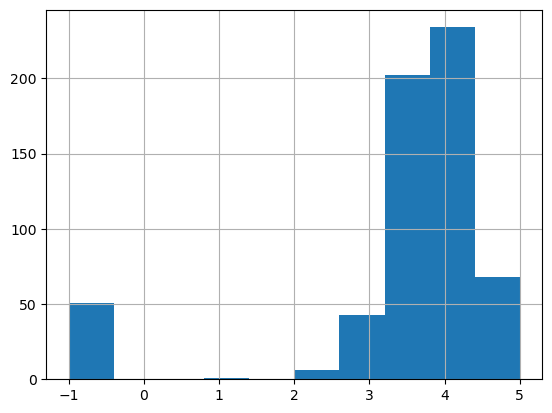

In [75]:
df.rating.hist()

<Axes: >

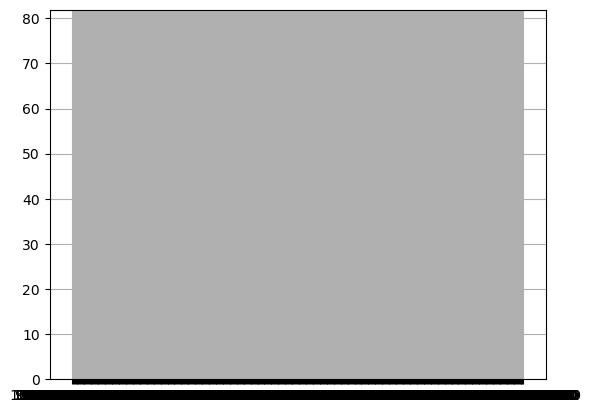

In [76]:
df.salary.hist()

<Axes: >

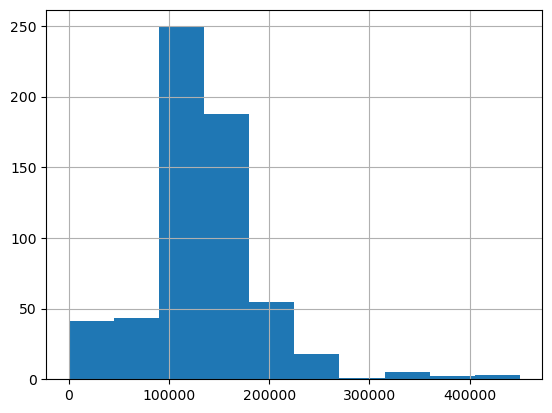

In [77]:
df.avg_salary.hist()